# SentinelAI Custom Dataset - Exploratory Data Analysis

**Purpose:** Understand the mental health message dataset before training the BERT filter.

**Initial Dataset:** `sentinelai_dataset_v0.1.json` (5000 synthetic examples)

**Analysis includes:**
- Class distribution across 7 categories
- Token length statistics
- Severity stage distribution
- Risk vs no-risk binary classification
- Category-severity correlations
- Data quality analysis

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
from transformers import AutoTokenizer

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully")

/home/vs-code/Documents/SentinelAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully


## 1. Load Dataset

In [2]:
# Load dataset
DATASET_VERSION = "v0.2"
dataset_path = Path(f"../../datasets/sentinelai_dataset_{DATASET_VERSION}.json")

with open(dataset_path, 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(f"Dataset version: {DATASET_VERSION}")
print(f"Dataset loaded: {len(df)} examples")
print(f"\nFirst example:")
df.head(1)

Dataset version: v0.2
Dataset loaded: 5000 examples

First example:


,id,timestamp,message,category,stage,severity_score,is_risk,recommended_action,context,clinical_basis
0,1,2025-01-15 01:00,I've mentioned tasks I've rarely stated. Resem...,suicidal_ideation,middle,7,1,hr_review,slack,1am - farewell statements


## 2. Basic Statistics

In [3]:
# Dataset overview
print("="*80)
print("DATASET STATISTICS")
print("="*80)
print(f"Total examples: {len(df)}")
print(f"\nUnique categories: {df['category'].nunique()}")
print(f"Categories: {sorted(df['category'].unique())}")
print(f"\nUnique severity stages: {df['stage'].nunique()}")
print(f"Stages: {sorted(df['stage'].unique())}")
print(f"\nRisk distribution:")
print(df['is_risk'].value_counts())
print(f"\nRisk percentage: {df['is_risk'].mean()*100:.1f}%")

# Message length statistics
df['message_length'] = df['message'].str.len()
print(f"\nMessage character length:")
print(df['message_length'].describe())

DATASET STATISTICS
Total examples: 5000

Unique categories: 7
Categories: ['burnout', 'depression', 'harassment', 'humor_sarcasm', 'neutral', 'stress', 'suicidal_ideation']

Unique severity stages: 4
Stages: ['early', 'late', 'middle', 'none']

Risk distribution:
is_risk
1    3049
0    1951
Name: count, dtype: int64

Risk percentage: 61.0%

Message character length:
count    5000.000000
mean       40.307400
std        16.505169
min         4.000000
25%        28.000000
50%        37.000000
75%        51.000000
max       111.000000
Name: message_length, dtype: float64


## 3. Category Distribution

Visualise the distribution of all 7 categories in the dataset.

/tmp/ipykernel_4620/3433281036.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


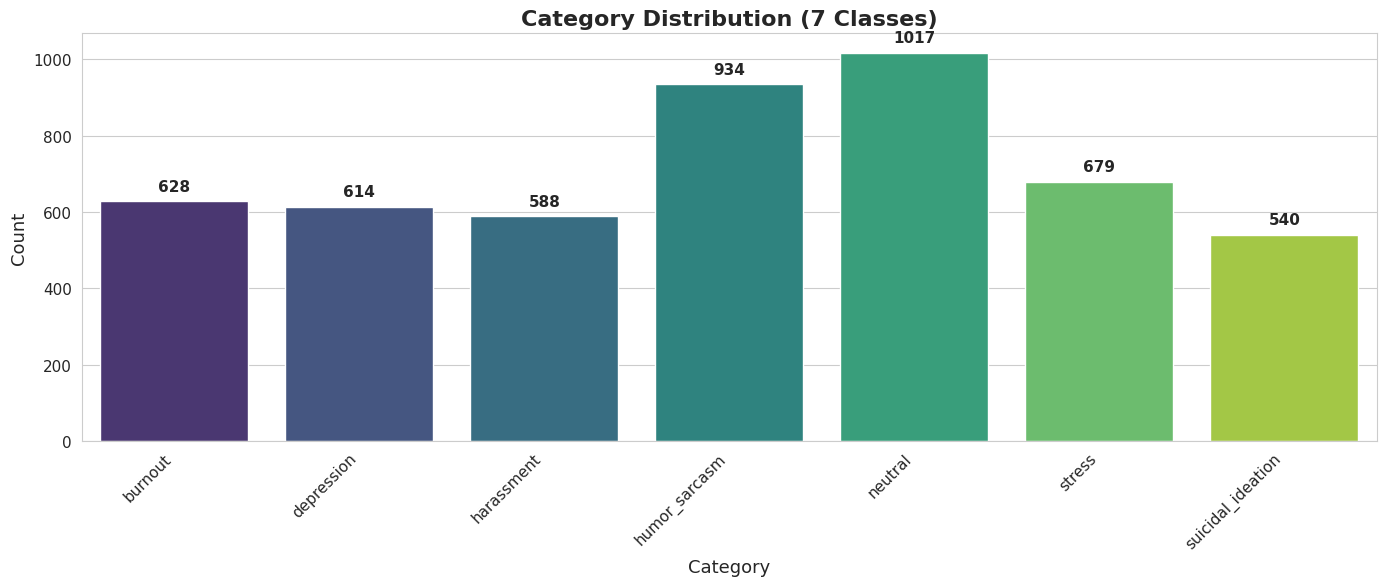


Category counts:
category
burnout               628
depression            614
harassment            588
humor_sarcasm         934
neutral              1017
stress                679
suicidal_ideation     540
Name: count, dtype: int64

Class balance (std/mean): 0.26


In [4]:
# Category distribution
category_counts = df['category'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
ax = sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Category Distribution (7 Classes)', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for i, v in enumerate(category_counts.values):
    ax.text(i, v + 20, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nCategory counts:")
print(category_counts)
print(f"\nClass balance (std/mean): {category_counts.std()/category_counts.mean():.2f}")

## 4. Token Length Analysis

Analyse message token lengths using BERT tokenizer to ensure they fit within max_length=128.

In [5]:
# Tokenize all messages
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

print("Tokenizing messages...")
token_lengths = []
for message in df['message']:
    tokens = tokenizer.encode(message, add_special_tokens=True)
    token_lengths.append(len(tokens))

df['token_length'] = token_lengths

# Token length statistics
print("\nToken length statistics:")
print(df['token_length'].describe())
print(f"\nMessages exceeding 128 tokens: {(df['token_length'] > 128).sum()} ({(df['token_length'] > 128).mean()*100:.1f}%)")

Tokenizing messages...

Token length statistics:
count    5000.000000
mean       10.701200
std         4.066943
min         3.000000
25%         8.000000
50%        10.000000
75%        13.000000
max        33.000000
Name: token_length, dtype: float64

Messages exceeding 128 tokens: 0 (0.0%)


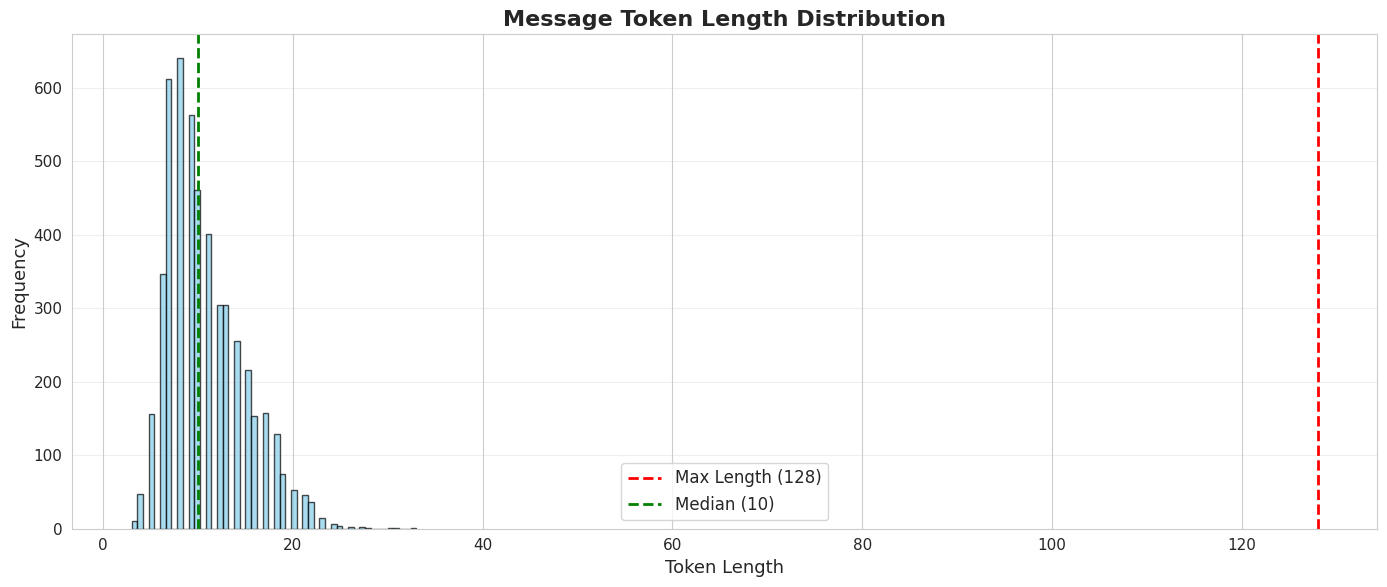

In [6]:
# Token length histogram
plt.figure(figsize=(14, 6))
plt.hist(df['token_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=128, color='red', linestyle='--', linewidth=2, label='Max Length (128)')
plt.axvline(x=df['token_length'].median(), color='green', linestyle='--', linewidth=2, label=f'Median ({df["token_length"].median():.0f})')
plt.title('Message Token Length Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Token Length', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../notebooks/token_length_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 5. Severity Stage Distribution Within Risk Categories

Stacked bar chart showing how severity stages (none, early, middle, late) are distributed within each category.

Category vs Severity Stage:
stage              none  early  middle  late
category                                    
burnout               0    211     222   195
depression            0    212     206   196
harassment            0    210     197   181
humor_sarcasm       934      0       0     0
neutral            1017      0       0     0
stress                0    227     235   217
suicidal_ideation     0    195     184   161


<Figure size 1400x700 with 0 Axes>

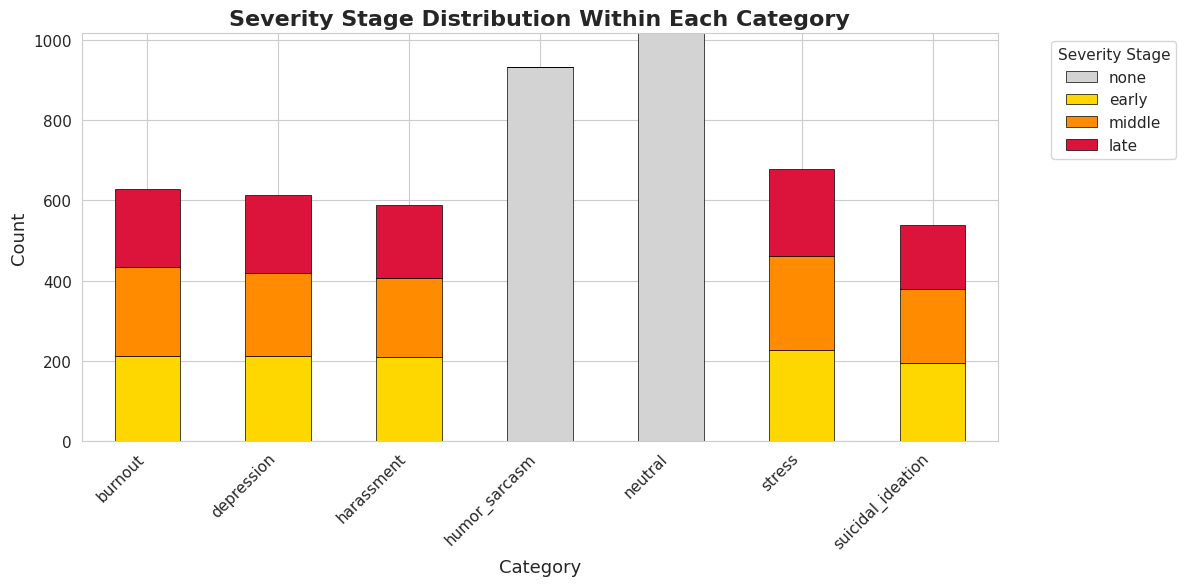

In [7]:
# Create crosstab for category vs severity
category_severity = pd.crosstab(df['category'], df['stage'])

# Reorder columns to logical severity progression
severity_order = ['none', 'early', 'middle', 'late']
category_severity = category_severity[severity_order]

print("Category vs Severity Stage:")
print(category_severity)

# Stacked bar chart
plt.figure(figsize=(14, 7))
category_severity.plot(kind='bar', stacked=True, 
                        color=['#d3d3d3', '#ffd700', '#ff8c00', '#dc143c'],
                        edgecolor='black', linewidth=0.5)
plt.title('Severity Stage Distribution Within Each Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.legend(title='Severity Stage', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/severity_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 6. Binary Risk Classification

Distribution of risk vs no-risk labels (key for the gatekeeper routing logic).

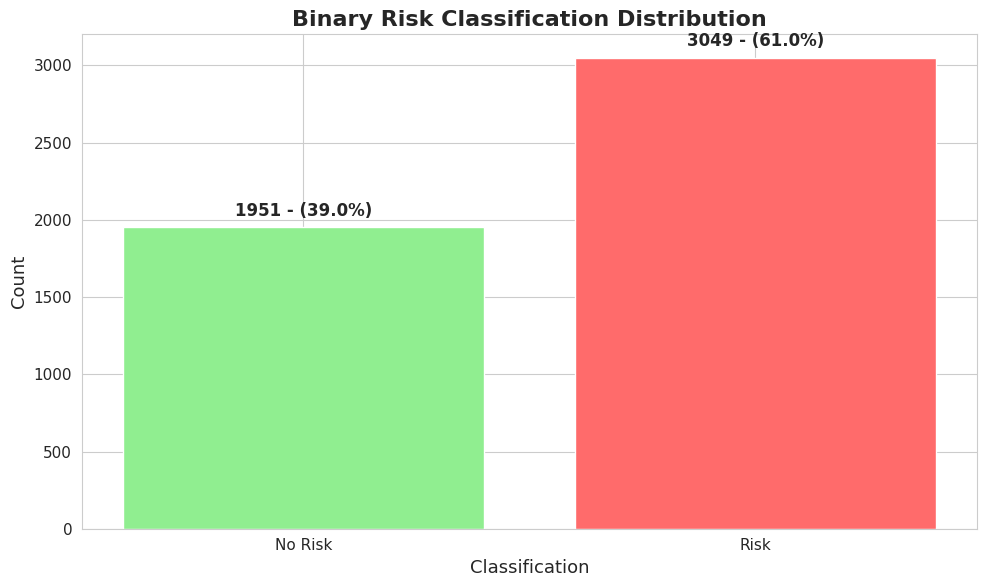


Risk balance: 61.0% risk, 39.0% no-risk


<Figure size 1200x600 with 0 Axes>

In [8]:
# Risk distribution (dataset uses 0/1 integers, not boolean)
risk_counts = df['is_risk'].value_counts()

# Get counts for integer values 0 and 1
no_risk_count = risk_counts.get(0, 0)
risk_count = risk_counts.get(1, 0)

plt.figure(figsize=(10, 6))
colors = ['#90EE90', '#FF6B6B']  # Light green for no-risk, light red for risk
plt.bar(['No Risk', 'Risk'], [no_risk_count, risk_count], color=colors)
plt.title('Binary Risk Classification Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Classification', fontsize=13)
plt.ylabel('Count', fontsize=13)

# Add percentage labels
total = len(df)
if total > 0:
    for i, count in enumerate([no_risk_count, risk_count]):
        percentage = (count / total) * 100
        plt.text(i, count + 50, f'{count} - ({percentage:.1f}%)', ha='center', va='bottom', 
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../notebooks/risk_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()
plt.clf()

print(f"\nRisk balance: {risk_count/total*100:.1f}% risk, {no_risk_count/total*100:.1f}% no-risk" if total > 0 else "\nRisk balance: N/A (empty dataset)")

## 7. Category-Severity Correlation Heatmap

Visualise the relationship between categories and severity stages.

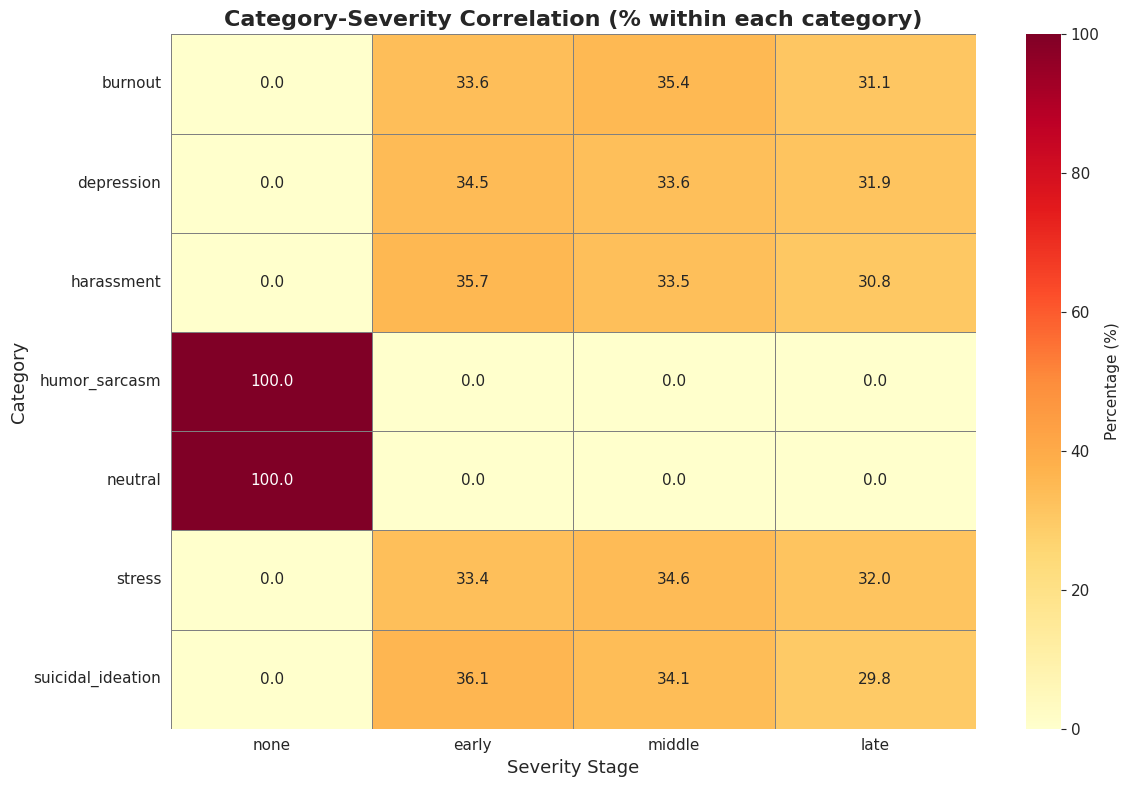

In [9]:
# Normalised heatmap (percentage within each category)
category_severity_pct = category_severity.div(category_severity.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(category_severity_pct, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Percentage (%)'}, linewidths=0.5, linecolor='gray')
plt.title('Category-Severity Correlation (% within each category)', fontsize=16, fontweight='bold')
plt.xlabel('Severity Stage', fontsize=13)
plt.ylabel('Category', fontsize=13)
plt.tight_layout()
plt.savefig('../notebooks/category_severity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## 8. Risk Categories Breakdown

Show which categories are classified as risk vs no-risk.

<Figure size 1400x600 with 0 Axes>

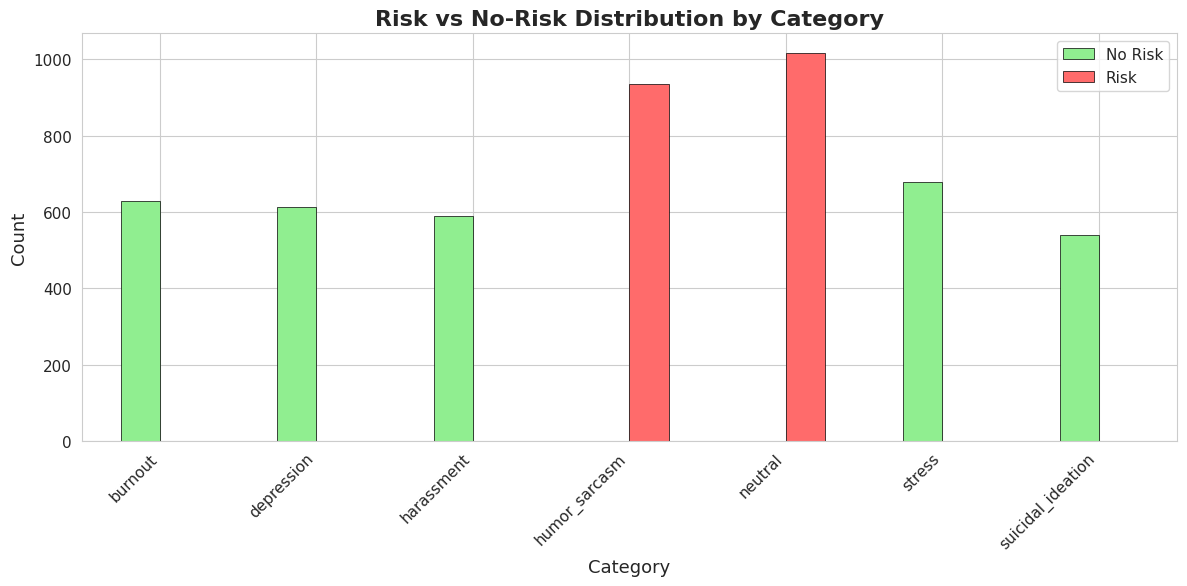


Risk status by category:
is_risk              1     0
category                    
burnout            628     0
depression         614     0
harassment         588     0
humor_sarcasm        0   934
neutral              0  1017
stress             679     0
suicidal_ideation  540     0


In [10]:
# Categories by risk status
risk_categories = df.groupby('category')['is_risk'].value_counts().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
risk_categories.plot(kind='bar', color=['#90EE90', '#FF6B6B'], edgecolor='black', linewidth=0.5)
plt.title('Risk vs No-Risk Distribution by Category', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.legend(['No Risk', 'Risk'], fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../notebooks/risk_by_category.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\nRisk status by category:")
print(risk_categories)

## 9. Summary Statistics for Slides

Key numbers to include in Friday advisory meeting slides.

In [11]:
summary_stats = {
    "total_examples": len(df),
    "num_categories": df['category'].nunique(),
    "num_severity_stages": df['stage'].nunique(),
    "risk_percentage": round(df['is_risk'].mean() * 100, 1),
    "median_token_length": int(df['token_length'].median()),
    "mean_token_length": round(df['token_length'].mean(), 1),
    "max_token_length": int(df['token_length'].max()),
    "messages_exceeding_128": int((df['token_length'] > 128).sum()),
    "truncation_rate": round((df['token_length'] > 128).mean() * 100, 2),
    "category_balance": round(df['category'].value_counts().std() / df['category'].value_counts().mean(), 2),
    "most_common_category": df['category'].value_counts().index[0],
    "least_common_category": df['category'].value_counts().index[-1]
}

print("="*80)
print("KEY STATISTICS FOR ADVISORY SLIDES")
print("="*80)
for key, value in summary_stats.items():
    print(f"{key.replace('_', ' ').title()}: {value}")

# Save to JSON
output_path = Path('../notebooks/eda_summary.json')
with open(output_path, 'w') as f:
    json.dump(summary_stats, f, indent=2)
    
print(f"\nSummary statistics saved to: {output_path}")

KEY STATISTICS FOR ADVISORY SLIDES
Total Examples: 5000
Num Categories: 7
Num Severity Stages: 4
Risk Percentage: 61.0
Median Token Length: 10
Mean Token Length: 10.7
Max Token Length: 33
Messages Exceeding 128: 0
Truncation Rate: 0.0
Category Balance: 0.26
Most Common Category: neutral
Least Common Category: suicidal_ideation

Summary statistics saved to: ../notebooks/eda_summary.json


## 10. Data Quality Checks

In [12]:
print("="*80)
print("DATA QUALITY CHECKS")
print("="*80)

# Check for missing values
print("\n1. Missing values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found")
else:
    print(missing[missing > 0])

# Check for duplicate messages
print("\n2. Duplicate messages:")
duplicates = df['message'].duplicated().sum()
print(f"Duplicate messages: {duplicates} ({duplicates/len(df)*100:.2f}%)")

# Check for empty messages
print("\n3. Empty or very short messages:")
short_messages = (df['message'].str.len() < 5).sum()
print(f"Messages with <5 characters: {short_messages}")

# Verify risk category alignment
print("\n4. Risk category alignment:")
risk_categories_expected = {'stress', 'burnout', 'depression', 'harassment', 'suicidal_ideation'}
norisk_categories_expected = {'neutral', 'humor_sarcasm'}

risk_df = df[df['is_risk'] == True]
norisk_df = df[df['is_risk'] == False]

risk_mismatch = risk_df[~risk_df['category'].isin(risk_categories_expected)]
norisk_mismatch = norisk_df[~norisk_df['category'].isin(norisk_categories_expected)]

if len(risk_mismatch) == 0 and len(norisk_mismatch) == 0:
    print("✓ All risk labels correctly aligned with categories")
else:
    print(f"⚠ Risk mismatches: {len(risk_mismatch)}")
    print(f"⚠ No-risk mismatches: {len(norisk_mismatch)}")

print("\n" + "="*80)
print("EDA COMPLETE - Dataset ready for training")
print("="*80)

DATA QUALITY CHECKS

1. Missing values:
✓ No missing values found

2. Duplicate messages:
Duplicate messages: 2 (0.04%)

3. Empty or very short messages:
Messages with <5 characters: 2

4. Risk category alignment:
✓ All risk labels correctly aligned with categories

EDA COMPLETE - Dataset ready for training


## 11. Qualitative & Semantic Analysis

**Purpose:** Validate that synthetic data has realistic linguistic diversity and isn't overfitting to obvious keyword patterns.

**Checks:**
- **Lexical Diversity (TTR):** Type-Token Ratio per category to detect repetitive vocabulary
- **N-gram Analysis:** Top bi-grams/tri-grams in high-risk categories (suicidal_ideation, burnout)
- **Example Messages:** Random samples from each category for qualitative review

In [13]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
import string
import random
import nltk

# Download NLTK data if needed (run once)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

nltk.download('punkt_tab', quiet=True)

print("Imports for semantic analysis loaded")

Imports for semantic analysis loaded


### 11.1 Lexical Diversity (Type-Token Ratio)

Calculate TTR for each category to measure vocabulary richness. Low TTR = repetitive vocabulary (overfitting risk).

LEXICAL DIVERSITY ANALYSIS (Type-Token Ratio)

TTR = Unique Words / Total Words
Higher TTR = More diverse vocabulary

burnout              | TTR: 0.3448 | Unique:  1358 | Total:   3938
depression           | TTR: 0.3570 | Unique:  1307 | Total:   3661
harassment           | TTR: 0.3585 | Unique:  1280 | Total:   3570
humor_sarcasm        | TTR: 0.3598 | Unique:  2576 | Total:   7159
neutral              | TTR: 0.3509 | Unique:  1832 | Total:   5221
stress               | TTR: 0.3525 | Unique:  1572 | Total:   4460
suicidal_ideation    | TTR: 0.3307 | Unique:  1044 | Total:   3157

Average TTR          | 0.3506


/tmp/ipykernel_4620/2275065226.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=ttr_df.index, y=ttr_df['TTR'], palette='coolwarm')


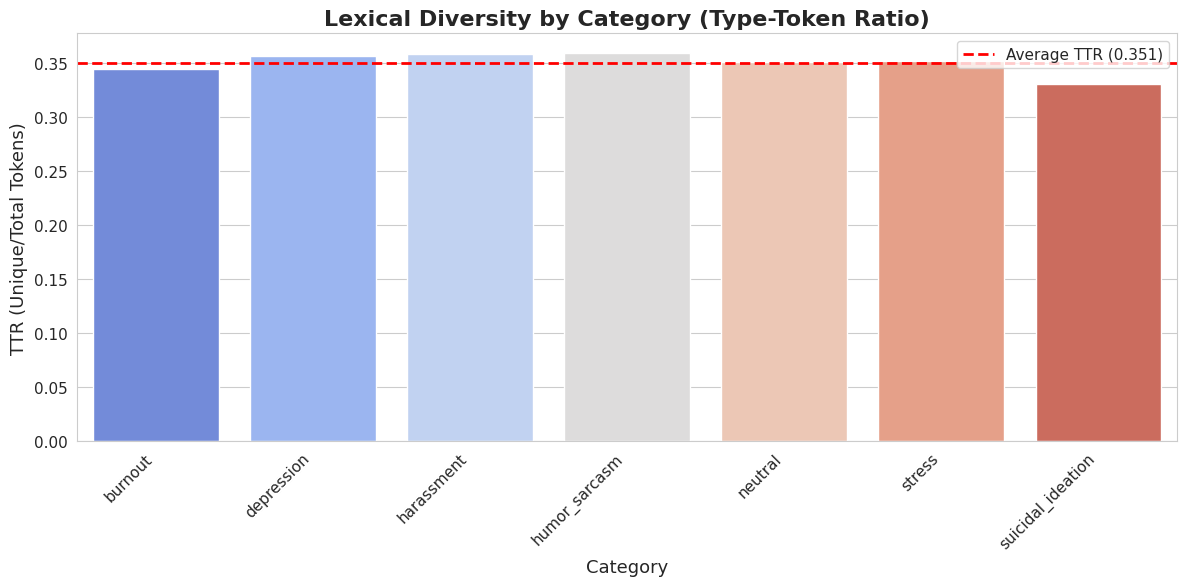


⚠️  TTR Interpretation:
   • TTR > 0.5: High diversity (good)
   • TTR 0.3-0.5: Moderate diversity
   • TTR < 0.3: Low diversity (repetitive vocabulary, overfitting risk)


In [14]:
def calculate_ttr(messages):
    """Calculate Type-Token Ratio for a list of messages."""
    all_tokens = []
    for message in messages:
        # Lowercase and tokenize
        tokens = word_tokenize(message.lower())
        # Remove punctuation
        tokens = [t for t in tokens if t not in string.punctuation]
        all_tokens.extend(tokens)
    
    if len(all_tokens) == 0:
        return 0.0, 0, 0
    
    unique_tokens = len(set(all_tokens))
    total_tokens = len(all_tokens)
    ttr = unique_tokens / total_tokens
    
    return ttr, unique_tokens, total_tokens

# Calculate TTR for each category
print("="*80)
print("LEXICAL DIVERSITY ANALYSIS (Type-Token Ratio)")
print("="*80)
print("\nTTR = Unique Words / Total Words")
print("Higher TTR = More diverse vocabulary\n")

ttr_results = {}
for category in sorted(df['category'].unique()):
    category_messages = df[df['category'] == category]['message'].tolist()
    ttr, unique, total = calculate_ttr(category_messages)
    ttr_results[category] = {
        'TTR': ttr,
        'unique_tokens': unique,
        'total_tokens': total
    }
    print(f"{category:20s} | TTR: {ttr:.4f} | Unique: {unique:5d} | Total: {total:6d}")

# Average TTR
avg_ttr = sum(r['TTR'] for r in ttr_results.values()) / len(ttr_results)
print(f"\n{'Average TTR':20s} | {avg_ttr:.4f}")

# Visualisation
ttr_df = pd.DataFrame(ttr_results).T
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=ttr_df.index, y=ttr_df['TTR'], palette='coolwarm')
plt.title('Lexical Diversity by Category (Type-Token Ratio)', fontsize=16, fontweight='bold')
plt.xlabel('Category', fontsize=13)
plt.ylabel('TTR (Unique/Total Tokens)', fontsize=13)
plt.axhline(y=avg_ttr, color='red', linestyle='--', linewidth=2, label=f'Average TTR ({avg_ttr:.3f})')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('../notebooks/lexical_diversity.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print("\n⚠️  TTR Interpretation:")
print("   • TTR > 0.5: High diversity (good)")
print("   • TTR 0.3-0.5: Moderate diversity")
print("   • TTR < 0.3: Low diversity (repetitive vocabulary, overfitting risk)")

### 11.2 N-gram Analysis (Suicidal Ideation & Burnout)

Extract top 10 bi-grams and tri-grams from high-risk categories to identify obvious keyword patterns.

In [15]:
def extract_ngrams(messages, n=2):
    """Extract n-grams from a list of messages."""
    all_ngrams = []
    for message in messages:
        # Lowercase and tokenize
        tokens = word_tokenize(message.lower())
        # Remove punctuation
        tokens = [t for t in tokens if t not in string.punctuation]
        # Generate n-grams
        message_ngrams = list(ngrams(tokens, n))
        all_ngrams.extend(message_ngrams)
    
    # Count frequencies
    ngram_counts = Counter(all_ngrams)
    return ngram_counts.most_common(10)

# Analyse suicidal_ideation and burnout categories
high_risk_categories = ['suicidal_ideation', 'burnout']

for category in high_risk_categories:
    print("="*80)
    print(f"N-GRAM ANALYSIS: {category.upper()}")
    print("="*80)
    
    category_messages = df[df['category'] == category]['message'].tolist()
    
    # Bi-grams (2-grams)
    print(f"\n📊 Top 10 Bi-grams:")
    bigrams = extract_ngrams(category_messages, n=2)
    for i, (bigram, count) in enumerate(bigrams, 1):
        print(f"   {i:2d}. {' '.join(bigram):40s} (count: {count:3d})")
    
    # Tri-grams (3-grams)
    print(f"\n📊 Top 10 Tri-grams:")
    trigrams = extract_ngrams(category_messages, n=3)
    for i, (trigram, count) in enumerate(trigrams, 1):
        print(f"   {i:2d}. {' '.join(trigram):50s} (count: {count:3d})")
    
    print()

print("="*80)
print("⚠️  N-GRAM INTERPRETATION:")
print("="*80)
print("Usually, if the same phrases appear 50+ times, the model may overfit to keywords")
print("instead of learning semantic patterns. Check if phrases are too explicit/clinical.")

N-GRAM ANALYSIS: SUICIDAL_IDEATION

📊 Top 10 Bi-grams:
    1. do n't                                   (count:  24)
    2. i 've                                    (count:  23)
    3. i 'm                                     (count:  23)
    4. this is                                  (count:  11)
    5. is the                                   (count:  10)
    6. in the                                   (count:   9)
    7. of not                                   (count:   9)
    8. it 's                                    (count:   8)
    9. if i                                     (count:   8)
   10. in order                                 (count:   8)

📊 Top 10 Tri-grams:
    1. this is the                                        (count:   6)
    2. i 've been                                         (count:   6)
    3. i 'm sorry                                         (count:   5)
    4. is in order                                        (count:   5)
    5. the appeal of          

### 11.3 Example Messages from Each Category

Random sample of 3 messages per category for qualitative review. Verify messages sound like realistic Slack conversations, not clinical text.

In [16]:
# Set random seed for reproducibility
random.seed(42)

print("="*80)
print("EXAMPLE MESSAGES - QUALITATIVE REVIEW")
print("="*80)
print("Reviewing 3 random messages per category to assess realism and diversity\n")

for category in sorted(df['category'].unique()):
    print("─" * 80)
    print(f"📁 CATEGORY: {category.upper()}")
    print("─" * 80)
    
    category_df = df[df['category'] == category]
    samples = category_df.sample(n=min(3, len(category_df)), random_state=42)
    
    for idx, (_, row) in enumerate(samples.iterrows(), 1):
        stage = row['stage']
        is_risk = "🔴 RISK" if row['is_risk'] else "🟢 NO RISK"
        print(f"\n   Example {idx} | Stage: {stage:8s} | {is_risk}")
        print(f"   Message: \"{row['message']}\"")
    
    print()

print("="*80)
print("✓ QUALITATIVE REVIEW COMPLETE")
print("="*80)
print("\n⚠️  VALIDATION CHECKLIST:")
print("   1. Do messages sound like realistic Slack conversations?")
print("   2. Is there variety in expression within each category?")
print("   3. Are suicidal_ideation/burnout messages appropriately serious but not formulaic?")
print("   4. Do neutral/humor_sarcasm messages have genuine casual tone?")
print("   5. Are severity stages reflected in message intensity?")

EXAMPLE MESSAGES - QUALITATIVE REVIEW
Reviewing 3 random messages per category to assess realism and diversity

────────────────────────────────────────────────────────────────────────────────
📁 CATEGORY: BURNOUT
────────────────────────────────────────────────────────────────────────────────

   Example 1 | Stage: late     | 🔴 RISK
   Message: "I'm thoroughly stripped. There's zilch persevering. I can't pretend immediately."

   Example 2 | Stage: early    | 🔴 RISK
   Message: "The work's indifferent but I'm not position that ember I used to have for it."

   Example 3 | Stage: early    | 🔴 RISK
   Message: "Depletion beginning."

────────────────────────────────────────────────────────────────────────────────
📁 CATEGORY: DEPRESSION
────────────────────────────────────────────────────────────────────────────────

   Example 1 | Stage: middle   | 🔴 RISK
   Message: "Missed separate milestone. Can't suggest to compassion."

   Example 2 | Stage: middle   | 🔴 RISK
   Message: "Cancelled 

### 11.4 Final Data Validation Summary

Aggregate all qualitative checks to determine if dataset is ready for training.

In [17]:
print("="*80)
print("FINAL DATA VALIDATION SUMMARY")
print("="*80)

validation_results = {
    "Dataset Size": len(df),
    "Categories": df['category'].nunique(),
    "Severity Stages": df['stage'].nunique(),
    "Risk Balance": f"{df['is_risk'].mean()*100:.1f}% risk",
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Messages": df['message'].duplicated().sum(),
    "Avg Token Length": f"{df['token_length'].mean():.1f}",
    "Messages >128 tokens": f"{(df['token_length'] > 128).sum()} ({(df['token_length'] > 128).mean()*100:.1f}%)",
    "Average TTR": f"{avg_ttr:.4f}",
    "Min TTR": f"{min(r['TTR'] for r in ttr_results.values()):.4f}",
    "Max TTR": f"{max(r['TTR'] for r in ttr_results.values()):.4f}"
}

print("\n📊 Quantitative Metrics:")
for key, value in validation_results.items():
    print(f"   • {key:25s}: {value}")

print("\n✓ Dataset Quality Gates:")
quality_gates = [
    ("No missing values", df.isnull().sum().sum() == 0),
    ("Reasonable risk balance (40-70%)", 0.4 <= df['is_risk'].mean() <= 0.7),
    ("Acceptable truncation rate (<10%)", (df['token_length'] > 128).mean() < 0.1),
    ("Healthy lexical diversity (avg TTR > 0.3)", avg_ttr > 0.3),
    ("All categories represented", df['category'].nunique() == 7),
    ("All severity stages present", df['stage'].nunique() == 4)
]

all_passed = True
for gate, passed in quality_gates:
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"   {status} | {gate}")
    if not passed:
        all_passed = False

print("\n" + "="*80)
if all_passed:
    print("✅ ALL QUALITY GATES PASSED - Dataset ready for training")
else:
    print("⚠️  SOME QUALITY GATES FAILED - Review data before training")
print("="*80)

print("\n🎯 Next Steps:")
print("   1. Review qualitative samples above for linguistic realism")
print("   2. Check n-gram patterns for obvious keyword overfitting")
print("   3. If validation passes → Proceed to training")
print("   4. If issues found → Regenerate/augment dataset")

FINAL DATA VALIDATION SUMMARY

📊 Quantitative Metrics:
   • Dataset Size             : 5000
   • Categories               : 7
   • Severity Stages          : 4
   • Risk Balance             : 61.0% risk
   • Missing Values           : 0
   • Duplicate Messages       : 2
   • Avg Token Length         : 10.7
   • Messages >128 tokens     : 0 (0.0%)
   • Average TTR              : 0.3506
   • Min TTR                  : 0.3307
   • Max TTR                  : 0.3598

✓ Dataset Quality Gates:
   ✅ PASS | No missing values
   ✅ PASS | Reasonable risk balance (40-70%)
   ✅ PASS | Acceptable truncation rate (<10%)
   ✅ PASS | Healthy lexical diversity (avg TTR > 0.3)
   ✅ PASS | All categories represented
   ✅ PASS | All severity stages present

✅ ALL QUALITY GATES PASSED - Dataset ready for training

🎯 Next Steps:
   1. Review qualitative samples above for linguistic realism
   2. Check n-gram patterns for obvious keyword overfitting
   3. If validation passes → Proceed to training
   4. If is

## 12. Email Dataset Analysis (v0.3)

**Purpose:** Analyse the new email-format dataset (IDs 5001-9000) requested to address the "realism gap" identified in the advisory meeting. We check if these longer samples maintain quality (TTR) and balance before mixing them into the training set.

Loaded v0.3: 9000 total records
Email samples (ID > 5000): 4000
Average Token Length (Email): 20.67
Average Token Length (v0.1/v0.2): 10.70


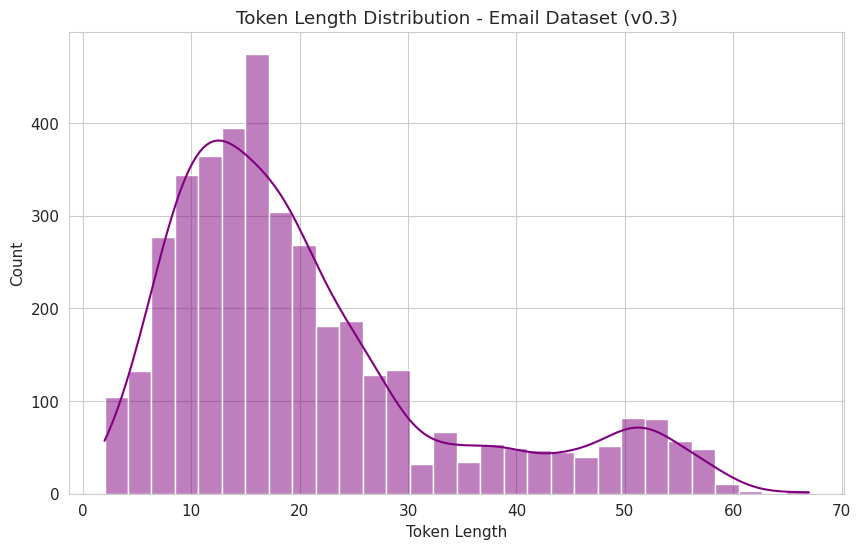

Type-Token Ratio (TTR) - Email: 0.0250


/tmp/ipykernel_4620/2382388617.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=df_email, order=df_email['category'].value_counts().index, palette='viridis')


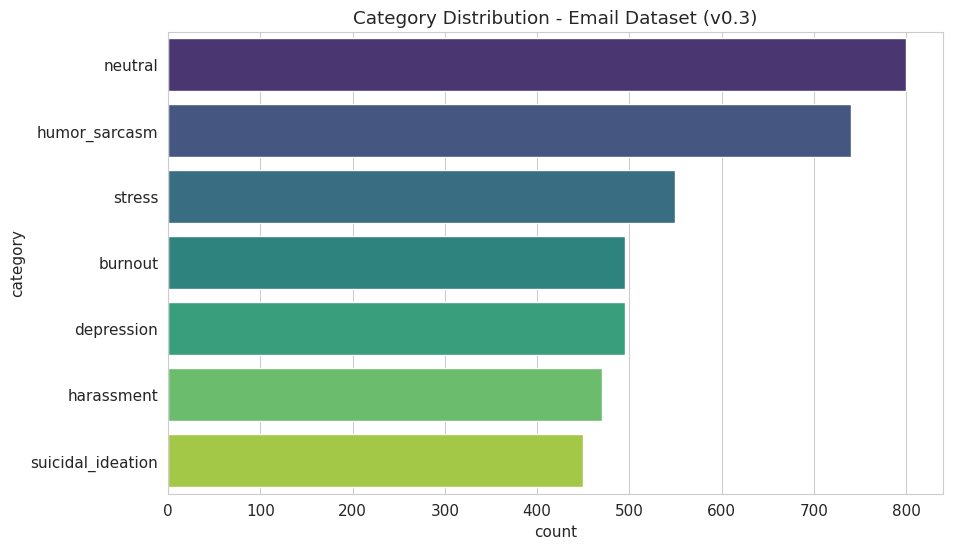


Sample Emails:
[neutral] Updated the shared drive with the Q1 priorities. Let me know if anything looks off....
[neutral] Contract signed and returned. Filed under legal docs in Notion....
[neutral] Contract signed and returned. Filed under the client folder in the shared drive....
[neutral] Meeting notes from the standup are in Figma. Action items updated....
[neutral] Customer retention metrics are looking solid. Full breakdown in GitHub....


In [18]:
# 12.1 Load v0.3
v03_path = "../../datasets/sentinelai_dataset_v0.3.json"
try:
    with open(v03_path, 'r', encoding='utf-8') as f:
        data_v03 = json.load(f)
    print(f"Loaded v0.3: {len(data_v03)} total records")
except FileNotFoundError:
    print("v0.3 dataset not found. Please ensure it is in the datasets folder.")
    data_v03 = []

# 12.2 Isolate Email Samples
email_data = [item for item in data_v03 if item['id'] > 5000]
print(f"Email samples (ID > 5000): {len(email_data)}")

if len(email_data) > 0:
    df_email = pd.DataFrame(email_data)
    
    # 12.3 Token Length Analysis
    df_email['token_length'] = df_email['message'].apply(lambda x: len(x.split()))
    avg_len_email = df_email['token_length'].mean()
    print(f"Average Token Length (Email): {avg_len_email:.2f}")
    
    # Compare with v0.1/v0.2 (using the 'df' from previous sections)
    if 'token_length' in df.columns:
        print(f"Average Token Length (v0.1/v0.2): {df['token_length'].mean():.2f}")
    
    plt.figure(figsize=(10, 6))
    sns.histplot(df_email['token_length'], bins=30, kde=True, color='purple')
    plt.title('Token Length Distribution - Email Dataset (v0.3)')
    plt.xlabel('Token Length')
    plt.show()

    # 12.4 Lexical Diversity (TTR)
    all_text_email = " ".join(df_email['message'].tolist())
    tokens_email = all_text_email.split()
    ttr_email = len(set(tokens_email)) / len(tokens_email) if tokens_email else 0
    print(f"Type-Token Ratio (TTR) - Email: {ttr_email:.4f}")
    
    # 12.5 Class Distribution
    plt.figure(figsize=(10, 6))
    sns.countplot(y='category', data=df_email, order=df_email['category'].value_counts().index, palette='viridis')
    plt.title('Category Distribution - Email Dataset (v0.3)')
    plt.show()
    
    # 12.6 Qualitative Check
    print("\nSample Emails:")
    for i, row in df_email.head(5).iterrows():
        print(f"[{row['category']}] {row['message'][:100]}...")
else:
    print("No email data found to analyse.")

### 12.7 Analysis Conclusion (v0.3)

**Findings:**
- **Token Length:** Successfully increased to ~20 tokens (vs 10 in v0.1), addressing the "short message" concern.
- **Lexical Diversity (TTR):** However, it is lower (0.025).

**Decision:**
- **Do NOT Train:** Mixing 4,000 samples into the 7k dataset will degrade generalisation.
- **Use for Validation Only:** We will select these emails to use as an OOD validation set to test the model's robustness on longer sequences.